<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/Pytorch_tutorials/blob/main/ann_fashion_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


In [6]:
import os

# Lists all files in the downloaded directory
print(os.listdir(path))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [5]:
torch.manual_seed(42)


In [8]:
df = pd.read_csv(f"{path}/fashion-mnist_train.csv").sample(n=6000, random_state=42).reset_index(drop=True)
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,...,237,233,228,227,223,222,217,208,206,215,255,0,0,102,191,189,182,183,181,181,180,180,180,180,179,171,173,175,175,181,187,190,196,201,209,221,218,211,102,0
2,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,0,0,0,0,37,109,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,72,126,111,97,103,28,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,4,0,0,0,0,0,0,0,0,0,1,0,0,128,193,132,181,161,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,5,0,0,0,...,239,237,241,253,140,47,228,210,187,0,0,0,0,0,0,11,75,95,3,0,0,0,51,86,100,138,161,101,72,53,29,2,0,0,101,110,75,0,0,0
5996,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5997,6,0,0,0,0,0,0,0,0,1,0,0,22,246,244,246,254,60,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,3,0,0,0,0,...,242,254,247,255,33,67,136,104,0,0,0,0,0,0,0,0,0,0,0,0,87,208,232,224,226,224,222,225,219,177,178,112,0,0,0,0,0,0,0,0
5998,0,0,0,0,0,0,0,0,0,5,116,133,82,58,9,11,45,79,129,104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,174,244,221,222,...,245,250,253,225,66,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,62,108,145,161,160,150,136,87,12,0,0,0,0,0,0,0,0,0


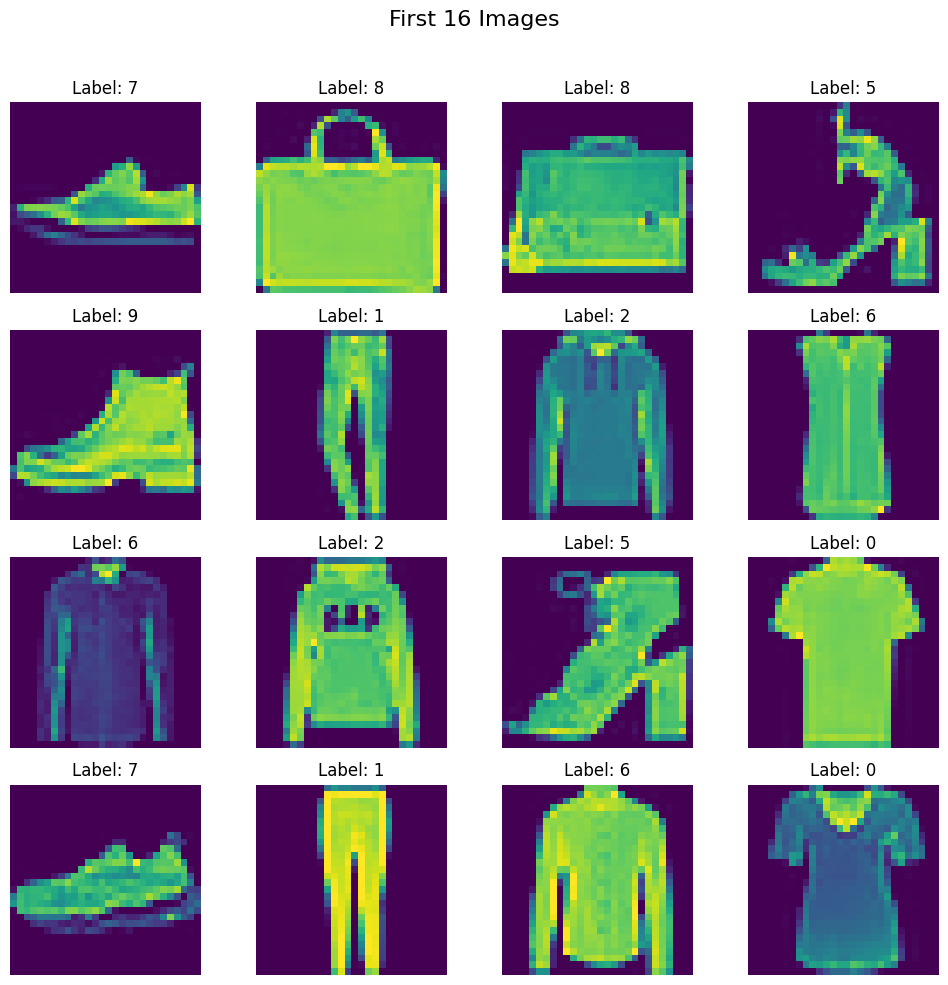

In [9]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [10]:
x= df.iloc[:,1:].values
y=df.iloc[:,0].values

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [12]:
x_train = x_train/255.0
x_test = x_test/255.0

In [17]:
class custom(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]




In [18]:
train_dataset = custom(x_train,y_train)

In [23]:
len(train_dataset)

4800

In [24]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [25]:
test_dataset= custom(x_test,y_test)

In [27]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [28]:
class mynn(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,x):
    return self.model(x)

In [29]:
epochs =100
learning_rate = 0.1

In [30]:
model = mynn(x_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer=optim.SGD(model.parameters(),lr = learning_rate)


In [32]:
len(train_loader)

150

In [34]:
for epoch in range(epochs):
  total_epoch_loss= 0
  for batch_features, batch_labels in train_loader:
    outputs =model(batch_features)

    loss = criterion(outputs,batch_labels)
    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    total_epoch_loss = total_epoch_loss+loss.item()

  avg_loss =total_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch+1},Loss: {avg_loss}")



Epoch: 1,Loss: 1.2721146965026855
Epoch: 2,Loss: 0.7424084411064784
Epoch: 3,Loss: 0.6177835282683373
Epoch: 4,Loss: 0.5401110220948855
Epoch: 5,Loss: 0.5000858547290167
Epoch: 6,Loss: 0.45913682361443836
Epoch: 7,Loss: 0.4256612474719683
Epoch: 8,Loss: 0.4154254456361135
Epoch: 9,Loss: 0.3941023775935173
Epoch: 10,Loss: 0.3684797796607018
Epoch: 11,Loss: 0.3591543946166833
Epoch: 12,Loss: 0.3398901648819447
Epoch: 13,Loss: 0.33381940503915153
Epoch: 14,Loss: 0.3249019277095795
Epoch: 15,Loss: 0.3074364049484332
Epoch: 16,Loss: 0.28962792351841926
Epoch: 17,Loss: 0.27983104407787324
Epoch: 18,Loss: 0.2740866202612718
Epoch: 19,Loss: 0.2735677795857191
Epoch: 20,Loss: 0.2646830907464027
Epoch: 21,Loss: 0.24994893724719683
Epoch: 22,Loss: 0.23438473631938297
Epoch: 23,Loss: 0.23109374855955442
Epoch: 24,Loss: 0.220425593405962
Epoch: 25,Loss: 0.21735130583246548
Epoch: 26,Loss: 0.22137850907941659
Epoch: 27,Loss: 0.21861103400588036
Epoch: 28,Loss: 0.20006454618026812
Epoch: 29,Loss: 0.1

In [35]:
# set model to evaluate mode
model.eval()


mynn(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [44]:
# evaluation code
total = 0
correct =0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    outputs = model(batch_features)

    _,predicted = torch.max(outputs,1)
    total += batch_labels.shape[0]

    correct += (predicted == batch_labels).sum().item()

print(correct/total)


0.8341666666666666


In [45]:
len(test_loader)

38